In [1]:
import warnings
warnings.filterwarnings('ignore',category=FutureWarning)
import pandas as pd
import numpy as np
import os
import re
import seaborn as sns
from datetime import datetime

In [2]:
folder_path = r'C:\Users\komal\Downloads\Linr_Reg_Data_Set\Linr_Reg_Data_Set'
if not os.path.exists(folder_path):
    print(f"❌ Folder not found at: {folder_path}")
else:
    print(f"✅ Folder exists: {folder_path}")

files = os.listdir(folder_path)
print("📂 All files in folder:")
for f in files:
    print(f)

dataframes = {}


for filename in os.listdir(folder_path):
    if filename.endswith('.csv'):
        file_path = os.path.join(folder_path, filename)  # Full path to file
        df = pd.read_csv(file_path)                      # Read CSV file
        dataframes[filename] = df                        # Store in dictionary
print("Loaded files:", list(dataframes.keys()))

✅ Folder exists: C:\Users\komal\Downloads\Linr_Reg_Data_Set\Linr_Reg_Data_Set
📂 All files in folder:
google_search_data.csv
product_manufacturer_list.csv
sales_data.csv
social_media_data.xlsx
Theme_list.csv
Theme_product_list.csv
Theme_product_list.xlsx
Loaded files: ['google_search_data.csv', 'product_manufacturer_list.csv', 'sales_data.csv', 'Theme_list.csv', 'Theme_product_list.csv']


In [3]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [4]:
for file in files:
    if file.lower().endswith('.xlsx'):
        file_path = os.path.join(folder_path, file)
        df = pd.read_excel(file_path)
        dataframes[file] = df

print("✅ All CSV & Excel files loaded:", list(dataframes.keys()))

✅ All CSV & Excel files loaded: ['google_search_data.csv', 'product_manufacturer_list.csv', 'sales_data.csv', 'Theme_list.csv', 'Theme_product_list.csv', 'social_media_data.xlsx', 'Theme_product_list.xlsx']


In [5]:
sales_data=dataframes["sales_data.csv"]

In [6]:
sales_data.head(2)

,system_calendar_key_N,product_id,sales_dollars_value,sales_units_value,sales_lbs_value
0,20160109,1,13927.0,934,18680
1,20160109,3,10289.0,1592,28646


In [7]:
sales_data.tail(2)

,system_calendar_key_N,product_id,sales_dollars_value,sales_units_value,sales_lbs_value
4526180,20181027,47544,3720.0,1246,4361
4526181,20181027,47545,1729.0,2016,378


In [8]:
sales_data['system_calendar_key_N'] = pd.to_datetime(sales_data['system_calendar_key_N'], format='%Y%m%d')


In [9]:
sales_data.head(2)

,system_calendar_key_N,product_id,sales_dollars_value,sales_units_value,sales_lbs_value
0,2016-01-09,1,13927.0,934,18680
1,2016-01-09,3,10289.0,1592,28646


In [10]:
sales_data.isnull().sum()

system_calendar_key_N    0
product_id               0
sales_dollars_value      0
sales_units_value        0
sales_lbs_value          0
dtype: int64

In [11]:
sales_data.describe().T

,count,mean,min,25%,50%,75%,max,std
system_calendar_key_N,4526182,2017-12-04 02:57:41.094581248,2016-01-09 00:00:00,2016-12-31 00:00:00,2017-12-09 00:00:00,2018-11-03 00:00:00,2019-10-05 00:00:00,NaN
product_id,4526182.0,28858.568988,1.0,15069.0,29981.0,41513.0,57317.0,15312.53656
sales_dollars_value,4526182.0,21594.541104,0.0,523.0,2655.0,11765.0,4395964.0,78180.565626
sales_units_value,4526182.0,5160.053381,1.0,80.0,403.0,1807.0,873998.0,26853.407825
sales_lbs_value,4526182.0,17153.392192,0.0,86.0,611.0,3770.0,11003100.0,127340.124382


In [12]:
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4526182 entries, 0 to 4526181
Data columns (total 5 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   system_calendar_key_N  datetime64[ns]
 1   product_id             int64         
 2   sales_dollars_value    float64       
 3   sales_units_value      int64         
 4   sales_lbs_value        int64         
dtypes: datetime64[ns](1), float64(1), int64(3)
memory usage: 172.7 MB


In [13]:
google_data=dataframes["google_search_data.csv"]

In [14]:
google_data.head(2)

,date,platform,searchVolume,Claim_ID,week_number,year_new
0,05-01-2014,google,349,916,1,2014
1,06-01-2014,google,349,916,2,2014


In [15]:
google_data.tail(2)

,date,platform,searchVolume,Claim_ID,week_number,year_new
181563,15-07-2019,walmart,42,622,29,2019
181564,02-09-2019,walmart,42,689,36,2019


In [16]:
google_data['platform'].value_counts()

platform
google     138115
amazon      23828
chewy       13352
walmart      6270
Name: count, dtype: int64

In [17]:
google_data['year_new'].value_counts

<bound method IndexOpsMixin.value_counts of 0         2014
1         2014
2         2014
3         2014
4         2014
          ... 
181560    2019
181561    2019
181562    2019
181563    2019
181564    2019
Name: year_new, Length: 181565, dtype: int64>

In [18]:
google_data.shape

(181565, 6)

In [19]:
google_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181565 entries, 0 to 181564
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   date          181565 non-null  object
 1   platform      181565 non-null  object
 2   searchVolume  181565 non-null  int64 
 3   Claim_ID      181565 non-null  int64 
 4   week_number   181565 non-null  int64 
 5   year_new      181565 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 8.3+ MB


In [20]:
google_data["date"]=pd.to_datetime(google_data["date"],format='%d-%m-%Y', errors='ignore')

In [21]:
google_data.head(2)

,date,platform,searchVolume,Claim_ID,week_number,year_new
0,2014-01-05,google,349,916,1,2014
1,2014-01-06,google,349,916,2,2014


In [22]:
google_data.sort_values(by='date',inplace=True)

In [23]:
google_data.head(2)

,date,platform,searchVolume,Claim_ID,week_number,year_new
1147,2014-01-01,google,889,922,1,2014
2365,2014-01-01,google,240,707,1,2014


In [24]:
google_data=google_data.reset_index(drop=True)

In [25]:
google_data.head(2)

,date,platform,searchVolume,Claim_ID,week_number,year_new
0,2014-01-01,google,889,922,1,2014
1,2014-01-01,google,240,707,1,2014


In [26]:
themes_data_pl=dataframes["Theme_product_list.csv"]

In [27]:
themes_data_pl.head(2)

,PRODUCT_ID,CLAIM_ID
0,1,0
1,2,0


In [28]:
social_data=dataframes["social_media_data.xlsx"]

In [29]:
social_data.head(2)

,Theme Id,published_date,total_post
0,148.0,2015-01-10 00:00:00,76
1,148.0,2015-10-10 00:00:00,31


In [30]:
social_data.shape

(533390, 3)

In [31]:
social_data.isnull().sum()

Theme Id          218511
published_date         0
total_post             0
dtype: int64

In [32]:
social_data=social_data.dropna(subset=['Theme Id'])

In [33]:
social_data.reset_index(drop=True,inplace=True)

In [34]:
social_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 314879 entries, 0 to 314878
Data columns (total 3 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Theme Id        314879 non-null  float64
 1   published_date  314879 non-null  object 
 2   total_post      314879 non-null  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 7.2+ MB


In [35]:
social_data['Theme Id']=social_data['Theme Id'].astype('int64')

C:\Users\komal\AppData\Local\Temp\ipykernel_15316\1390294065.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  social_data['Theme Id']=social_data['Theme Id'].astype('int64')


In [36]:
social_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 314879 entries, 0 to 314878
Data columns (total 3 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   Theme Id        314879 non-null  int64 
 1   published_date  314879 non-null  object
 2   total_post      314879 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 7.2+ MB


In [37]:
product_manu=dataframes['product_manufacturer_list.csv']

In [38]:
product_manu.head(2)

,PRODUCT_ID,Vendor,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,1,Others,NaN,NaN,NaN,NaN,NaN
1,2,Others,NaN,NaN,NaN,NaN,NaN


In [39]:
product_manu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67175 entries, 0 to 67174
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   PRODUCT_ID  67175 non-null  int64  
 1   Vendor      67175 non-null  object 
 2   Unnamed: 2  0 non-null      float64
 3   Unnamed: 3  0 non-null      float64
 4   Unnamed: 4  0 non-null      float64
 5   Unnamed: 5  0 non-null      float64
 6   Unnamed: 6  0 non-null      float64
dtypes: float64(5), int64(1), object(1)
memory usage: 3.6+ MB


In [40]:
for col in product_manu.columns:
    print(col)

PRODUCT_ID
Vendor
Unnamed: 2
Unnamed: 3
Unnamed: 4
Unnamed: 5
Unnamed: 6


In [41]:
product_manu=product_manu[['PRODUCT_ID','Vendor']]

In [42]:
product_manu.isnull().sum()

PRODUCT_ID    0
Vendor        0
dtype: int64

In [43]:
product_manu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67175 entries, 0 to 67174
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   PRODUCT_ID  67175 non-null  int64 
 1   Vendor      67175 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.0+ MB


In [44]:
themes_list=dataframes["Theme_list.csv"]

In [45]:
themes_list.head()

,CLAIM_ID,Claim Name
0,0,No Claim
1,8,low carb
2,15,beans
3,16,cocoa
4,26,vanilla


In [46]:
themes_list.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   CLAIM_ID    208 non-null    int64 
 1   Claim Name  208 non-null    object
dtypes: int64(1), object(1)
memory usage: 3.4+ KB


In [47]:
themes_list.isnull().sum()

CLAIM_ID      0
Claim Name    0
dtype: int64

In [48]:
themes_list.shape

(208, 2)

In [49]:
themes_list['CLAIM_ID'].nunique()

208

In [50]:
themes_list['Claim Name'].unique()

array(['No Claim', 'low carb', 'beans', 'cocoa', 'vanilla', 'stroganoff',
       'cumin', 'high/source of protein', 'no additives/preservatives',
       'buckwheat', 'tutti frutti', 'ethical - not specific', 'brown ale',
       'french bisque', 'pheasant', 'whitebait', 'gmo free',
       'low calorie', 'peach', 'crab', 'nuts', 'venison', 'fruit',
       'convenience - easy-to-prepare', 'anchovy', 'pomegranate',
       'scallop', 'american gumbo', 'tuna', 'low sodium', 'low sugar',
       'french', 'chicken', 'ethical - packaging', 'cherry',
       'vitamin/mineral fortified', 'liver', 'red raspberry', 'cookie',
       'pollock', 'blueberry', 'bone health', 'prebiotic', 'poultry',
       'cheddar cheese', 'energy/alertness', 'halal', 'herbs', 'pizza',
       'american southwest style', 'salmon', 'beef hamburger', 'tilapia',
       'mackerel', 'peanut', 'lobster', 'sea salt', 'soy foods',
       'apple cinnamon', 'gingerbread', 'vegetarian', 'ethnic & exotic',
       'cream', 'berry', 'g

In [51]:
 sales_data.head(2)

,system_calendar_key_N,product_id,sales_dollars_value,sales_units_value,sales_lbs_value
0,2016-01-09,1,13927.0,934,18680
1,2016-01-09,3,10289.0,1592,28646


In [52]:
social_data.head(2)

,Theme Id,published_date,total_post
0,148,2015-01-10 00:00:00,76
1,148,2015-10-10 00:00:00,31


In [53]:
social_data.rename(columns={'Theme Id':'CLAIM_ID'},inplace=True)

C:\Users\komal\AppData\Local\Temp\ipykernel_15316\2644833392.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  social_data.rename(columns={'Theme Id':'CLAIM_ID'},inplace=True)


In [54]:
social_data.head(2)

,CLAIM_ID,published_date,total_post
0,148,2015-01-10 00:00:00,76
1,148,2015-10-10 00:00:00,31


In [55]:
product_manu.head(2)

,PRODUCT_ID,Vendor
0,1,Others
1,2,Others


In [56]:
themes_list.head(2)

,CLAIM_ID,Claim Name
0,0,No Claim
1,8,low carb


In [57]:
themes_data_pl.head(2)

,PRODUCT_ID,CLAIM_ID
0,1,0
1,2,0


In [58]:
google_data.head(2)

,date,platform,searchVolume,Claim_ID,week_number,year_new
0,2014-01-01,google,889,922,1,2014
1,2014-01-01,google,240,707,1,2014


In [59]:
sales_data.rename(columns={'product_id':'PRODUCT_ID'},inplace=True)

In [60]:
sales_data.head(2)

,system_calendar_key_N,PRODUCT_ID,sales_dollars_value,sales_units_value,sales_lbs_value
0,2016-01-09,1,13927.0,934,18680
1,2016-01-09,3,10289.0,1592,28646


In [61]:
google_data.rename(columns={'Claim_ID':'CLAIM_ID'},inplace=True)

In [62]:
google_data.head(2)

,date,platform,searchVolume,CLAIM_ID,week_number,year_new
0,2014-01-01,google,889,922,1,2014
1,2014-01-01,google,240,707,1,2014


In [63]:
sales_data.shape

(4526182, 5)

In [64]:
product_manu.shape

(67175, 2)

In [65]:
themes_data_pl.shape

(91485, 2)

In [66]:
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4526182 entries, 0 to 4526181
Data columns (total 5 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   system_calendar_key_N  datetime64[ns]
 1   PRODUCT_ID             int64         
 2   sales_dollars_value    float64       
 3   sales_units_value      int64         
 4   sales_lbs_value        int64         
dtypes: datetime64[ns](1), float64(1), int64(3)
memory usage: 172.7 MB


In [67]:
product_manu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67175 entries, 0 to 67174
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   PRODUCT_ID  67175 non-null  int64 
 1   Vendor      67175 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.0+ MB


In [68]:
themes_data_pl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91485 entries, 0 to 91484
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   PRODUCT_ID  91485 non-null  int64
 1   CLAIM_ID    91485 non-null  int64
dtypes: int64(2)
memory usage: 1.4 MB


In [69]:
sales_product_mfg=pd.merge(sales_data,product_manu,how='left',on='PRODUCT_ID')

In [70]:
sales_product_mfg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4526182 entries, 0 to 4526181
Data columns (total 6 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   system_calendar_key_N  datetime64[ns]
 1   PRODUCT_ID             int64         
 2   sales_dollars_value    float64       
 3   sales_units_value      int64         
 4   sales_lbs_value        int64         
 5   Vendor                 object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 207.2+ MB


In [71]:
sales_product_mfg.shape

(4526182, 6)

In [72]:
sales_product_mfg.isnull().sum()

system_calendar_key_N    0
PRODUCT_ID               0
sales_dollars_value      0
sales_units_value        0
sales_lbs_value          0
Vendor                   0
dtype: int64

In [73]:
sales_product_mfg.head(2)

,system_calendar_key_N,PRODUCT_ID,sales_dollars_value,sales_units_value,sales_lbs_value,Vendor
0,2016-01-09,1,13927.0,934,18680,Others
1,2016-01-09,3,10289.0,1592,28646,Others


In [74]:
sales_product_mfg_themes=pd.merge(sales_product_mfg,themes_data_pl,how='left',on='PRODUCT_ID')

In [75]:
sales_product_mfg_themes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7767420 entries, 0 to 7767419
Data columns (total 7 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   system_calendar_key_N  datetime64[ns]
 1   PRODUCT_ID             int64         
 2   sales_dollars_value    float64       
 3   sales_units_value      int64         
 4   sales_lbs_value        int64         
 5   Vendor                 object        
 6   CLAIM_ID               int64         
dtypes: datetime64[ns](1), float64(1), int64(4), object(1)
memory usage: 414.8+ MB


In [76]:
sales_product_mfg_themes.shape

(7767420, 7)

In [77]:
sales_product_mfg_themes.isnull().sum()

system_calendar_key_N    0
PRODUCT_ID               0
sales_dollars_value      0
sales_units_value        0
sales_lbs_value          0
Vendor                   0
CLAIM_ID                 0
dtype: int64

In [78]:
sales_product_mfg_themes_name=pd.merge(sales_product_mfg_themes,themes_list,how='left',on='CLAIM_ID')

In [79]:
sales_product_mfg_themes_name.isnull().sum()

system_calendar_key_N    0
PRODUCT_ID               0
sales_dollars_value      0
sales_units_value        0
sales_lbs_value          0
Vendor                   0
CLAIM_ID                 0
Claim Name               0
dtype: int64

In [80]:
sales_product_mfg_themes_name['Claim Name'].value_counts()

Claim Name
No Claim                         2045703
low carb                         1668808
no additives/preservatives        826406
apple cinnamon                    520679
stroganoff                        387999
pollock                           338116
american southwest style          218897
blueberry                         218897
gmo free                          215635
buckwheat                         175912
pizza                             146173
cookie                            146173
ethnic & exotic                   132719
crab                              129212
salmon                             84542
chicken                            73382
low sodium                         60132
soy foods                          55961
french bisque                      42655
beans                              35758
herbs                              26954
cocoa                              26367
brown ale                          25085
high/source of protein             24818
ginge

In [81]:
sales_product_mfg_themes_name.head(2)

,system_calendar_key_N,PRODUCT_ID,sales_dollars_value,sales_units_value,sales_lbs_value,Vendor,CLAIM_ID,Claim Name
0,2016-01-09,1,13927.0,934,18680,Others,0,No Claim
1,2016-01-09,3,10289.0,1592,28646,Others,0,No Claim


In [82]:
base_dataset = sales_product_mfg_themes_name[((sales_product_mfg_themes_name['Claim Name'] == 'No Claim') |
                                              (sales_product_mfg_themes_name['Claim Name'] == 'low carb') | (sales_product_mfg_themes_name['Claim Name'] == 'no additives/preservatives'))]

In [83]:
base_dataset.shape

(4540917, 8)

In [84]:
base_dataset['Claim Name'].value_counts()

Claim Name
No Claim                      2045703
low carb                      1668808
no additives/preservatives     826406
Name: count, dtype: int64

In [85]:
base_dataset = base_dataset[['PRODUCT_ID','sales_lbs_value','sales_units_value','Vendor','CLAIM_ID','sales_dollars_value']]

In [86]:
base_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4540917 entries, 0 to 7767418
Data columns (total 6 columns):
 #   Column               Dtype  
---  ------               -----  
 0   PRODUCT_ID           int64  
 1   sales_lbs_value      int64  
 2   sales_units_value    int64  
 3   Vendor               object 
 4   CLAIM_ID             int64  
 5   sales_dollars_value  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 242.5+ MB


In [87]:
base_dataset.head(2)

,PRODUCT_ID,sales_lbs_value,sales_units_value,Vendor,CLAIM_ID,sales_dollars_value
0,1,18680,934,Others,0,13927.0
1,3,28646,1592,Others,0,10289.0


In [88]:
base_dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
PRODUCT_ID,4540917.0,29334.849743,15035.848252,1.0,16947.0,30679.0,41354.0,57317.0
sales_lbs_value,4540917.0,15764.537620,125071.286769,0.0,87.0,604.0,3510.0,11003100.0
sales_units_value,4540917.0,5014.114079,26522.414108,1.0,84.0,411.0,1808.0,873998.0
CLAIM_ID,4540917.0,10.219677,14.500488,0.0,0.0,8.0,8.0,40.0
sales_dollars_value,4540917.0,20211.998146,74140.362279,0.0,547.0,2737.0,11657.0,4395964.0


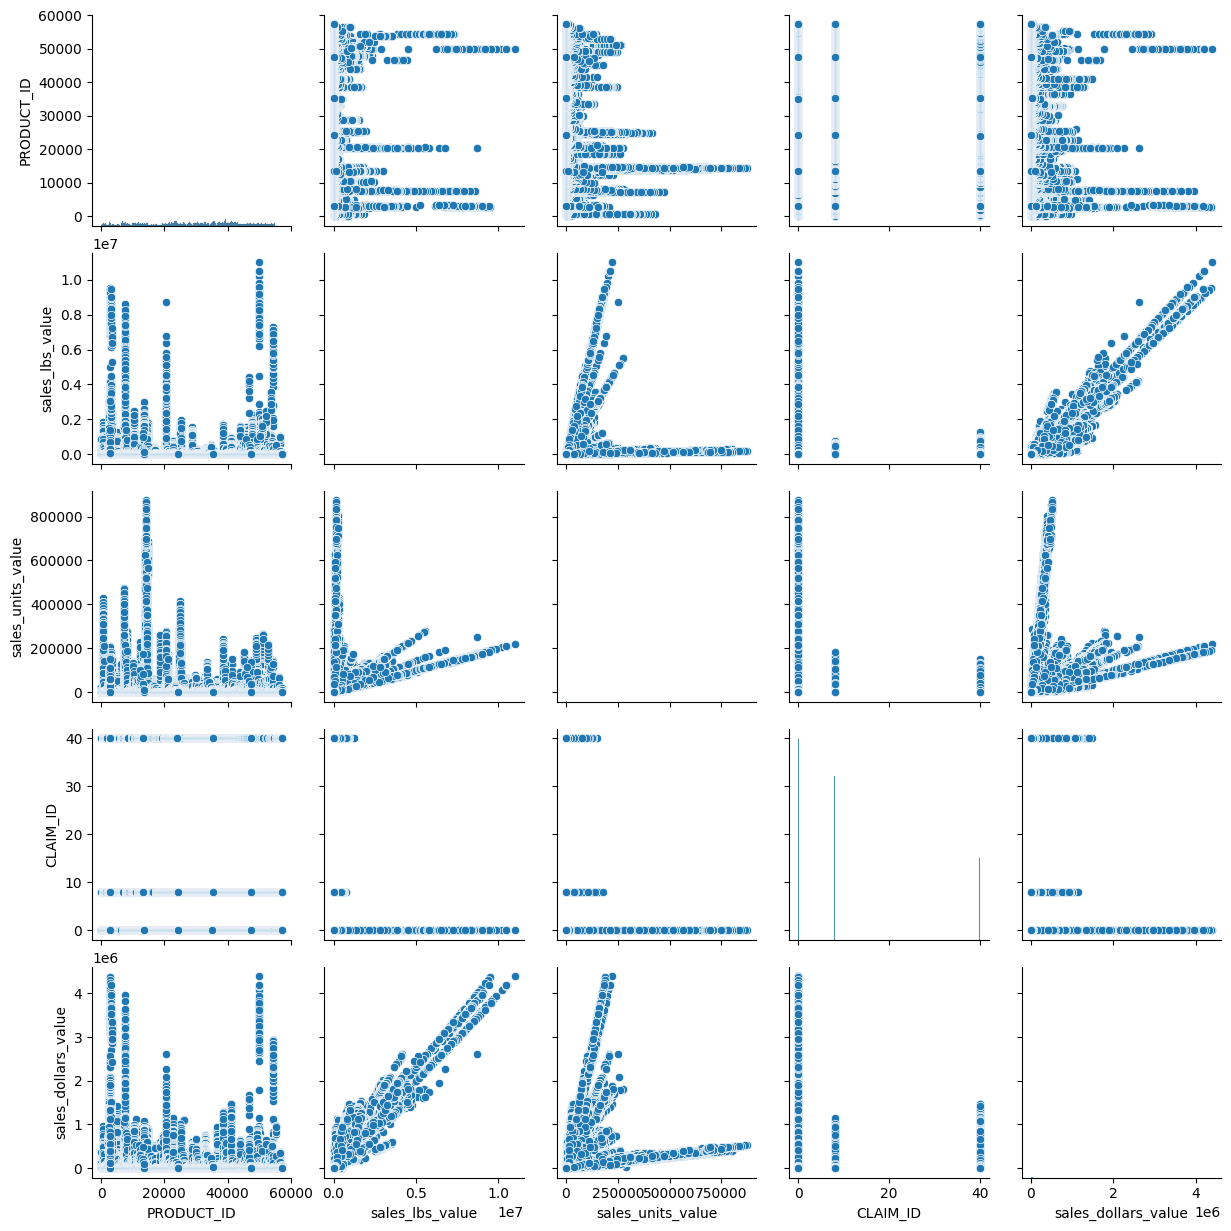

In [89]:
sns.pairplot(base_dataset)

In [90]:
import matplotlib.pyplot as plt

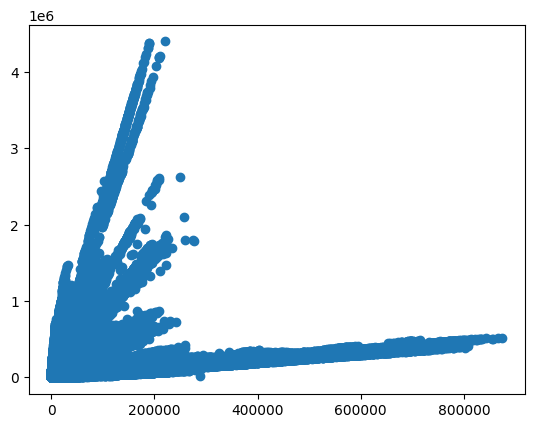

In [91]:
plt.scatter(base_dataset['sales_units_value'],base_dataset['sales_dollars_value'])

In [92]:
cat=[i for i in base_dataset.columns if i not in base_dataset.describe().columns]

In [93]:
cat

['Vendor']

In [94]:
base_dataset['Vendor'].unique()

array(['Others', 'A', 'Private Label', 'B', 'E', 'D', 'F', 'G', 'H'],
      dtype=object)

In [95]:
#label encoding
from sklearn.preprocessing import LabelEncoder
def label_encoders(data,cat):
    le=LabelEncoder()
    for i in cat:
        le.fit(data[i])
        x=le.transform(data[i])
        data[i]=x
    return data

In [96]:
base_data_LE=label_encoders(base_dataset,cat)

In [97]:
base_data_LE.head(2)

,PRODUCT_ID,sales_lbs_value,sales_units_value,Vendor,CLAIM_ID,sales_dollars_value
0,1,18680,934,7,0,13927.0
1,3,28646,1592,7,0,10289.0


In [98]:
base_data_LE["Vendor"].unique()

array([7, 0, 8, 1, 3, 2, 4, 5, 6])

In [99]:
base_data_LE.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4540917 entries, 0 to 7767418
Data columns (total 6 columns):
 #   Column               Dtype  
---  ------               -----  
 0   PRODUCT_ID           int64  
 1   sales_lbs_value      int64  
 2   sales_units_value    int64  
 3   Vendor               int64  
 4   CLAIM_ID             int64  
 5   sales_dollars_value  float64
dtypes: float64(1), int64(5)
memory usage: 242.5 MB


In [100]:
x=base_data_LE.drop('sales_dollars_value',axis=1)
y=base_data_LE['sales_dollars_value']

In [101]:
x.head(2)

,PRODUCT_ID,sales_lbs_value,sales_units_value,Vendor,CLAIM_ID
0,1,18680,934,7,0
1,3,28646,1592,7,0


In [102]:
y.head(2)

0    13927.0
1    10289.0
Name: sales_dollars_value, dtype: float64

In [103]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.20)

In [104]:
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(3632733, 5) (908184, 5) (3632733,) (908184,)


In [105]:
from sklearn.linear_model import LinearRegression
ln=LinearRegression()
ln.fit(X_train,y_train)
ln.predict(X_test)

array([  6516.122056  ,   6907.93070207,   9071.23341067, ...,
        20726.84292323, 351211.31381794,   7117.1328891 ])

In [106]:
abs(y_test.values-ln.predict(X_test)).sum()

np.float64(12972612192.909681)

In [107]:
from sklearn.linear_model import Lasso
ls=Lasso()
ls.fit(X_train,y_train)
ls.predict(X_test)

abs(y_test.values-ls.predict(X_test)).sum()

np.float64(12972621599.007277)

In [108]:
from sklearn.linear_model import Ridge
rd=Ridge()
rd.fit(X_train,y_train)
rd.predict(X_test)

abs(y_test.values-rd.predict(X_test)).sum()

np.float64(12972612198.047453)

In [109]:
#model validation
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [110]:
validation_table=[]
for i in [LinearRegression,Lasso,Ridge]:
    rd=i()
    rd.fit(X_train,y_train)
    rd.predict(X_test)
    mae=mean_absolute_error(y_test.values,rd.predict(X_test))
    mse=mean_squared_error(y_test.values,rd.predict(X_test))
    rmse=np.sqrt(mean_squared_error(y_test.values,rd.predict(X_test)))
    mape=(((abs(y_test.values-rd.predict(X_test))/y_test.values)*100).sum())*(1/y_test.shape[0])
    rsquare=r2_score(y_test.values,rd.predict(X_test))
    validation_table.append([i,mae,mse,rmse,mape,rsquare])

C:\Users\komal\AppData\Local\Temp\ipykernel_15316\1946313057.py:9: RuntimeWarning: divide by zero encountered in divide
  mape=(((abs(y_test.values-rd.predict(X_test))/y_test.values)*100).sum())*(1/y_test.shape[0])
C:\Users\komal\AppData\Local\Temp\ipykernel_15316\1946313057.py:9: RuntimeWarning: divide by zero encountered in divide
  mape=(((abs(y_test.values-rd.predict(X_test))/y_test.values)*100).sum())*(1/y_test.shape[0])
C:\Users\komal\AppData\Local\Temp\ipykernel_15316\1946313057.py:9: RuntimeWarning: divide by zero encountered in divide
  mape=(((abs(y_test.values-rd.predict(X_test))/y_test.values)*100).sum())*(1/y_test.shape[0])


In [111]:
validation_table=pd.DataFrame(validation_table)

In [112]:
validation_table.columns=["model name","mae","mse","rmse","mape","rsquare"]

In [113]:
validation_table

,model name,mae,mse,rmse,mape,rsquare
0,<class 'sklearn.linear_model._base.LinearRegre...,14284.123254,1.321547e+09,36353.091708,inf,0.756937
1,<class 'sklearn.linear_model._coordinate_desce...,14284.133611,1.321547e+09,36353.092280,inf,0.756937
2,<class 'sklearn.linear_model._ridge.Ridge'>,14284.123259,1.321547e+09,36353.091708,inf,0.756937


In [114]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import BaggingRegressor

In [115]:
def model_validation(x):
    if x=="train":
        validation_table_train=[]
        models=[LinearRegression,Lasso,Ridge,RandomForestRegressor,DecisionTreeRegressor,BaggingRegressor]
        for i in models:
            rd=i()
            rd.fit(X_train,y_train)
            rd.predict(X_train)
            mae=mean_absolute_error(y_train.values,rd.predict(X_train))
            mse=mean_squared_error(y_train.values,rd.predict(X_train))
            rmse=np.sqrt(mean_squared_error(y_train.values,rd.predict(X_train)))
            mape=(((abs(y_train.values-rd.predict(X_train))/y_train.values)*100).sum())*(1/y_train.shape[0])
            rsquare=r2_score(y_train.values,rd.predict(X_train))
            validation_table_train.append([i,mae,mse,rmse,mape,rsquare])
        validation_table_train=pd.DataFrame(validation_table_train)
        validation_table_train.columns=["model name","mae","mse","rmse","mape","rsquare"]
        validation_table_train
        return validation_table_train
    else:
        validation_table=[]
        models=[LinearRegression,Lasso,Ridge,DecisionTreeRegressor,RandomForestRegressor,BaggingRegressor]
        for i in models:
            rd=i()
            rd.fit(X_train,y_train)
            rd.predict(X_test)
            mae=mean_absolute_error(y_test.values,rd.predict(X_test))
            mse=mean_squared_error(y_test.values,rd.predict(X_test))
            rmse=np.sqrt(mean_squared_error(y_test.values,rd.predict(X_test)))
            mape=(((abs(y_test.values-rd.predict(X_test))/y_test.values)*100).sum())*(1/y_test.shape[0])
            rsquare=r2_score(y_test.values,rd.predict(X_test))
            validation_table.append([i,mae,mse,rmse,mape,rsquare])
        validation_table=pd.DataFrame(validation_table)
        validation_table.columns=["model name","mae","mse","rmse","mape","rsquare"]
        return validation_table

In [116]:
pd.options.display.float_format='{:0.2f}'.format

In [ ]:
model_validation("train")

C:\Users\komal\AppData\Local\Temp\ipykernel_15316\1692341635.py:12: RuntimeWarning: divide by zero encountered in divide
  mape=(((abs(y_train.values-rd.predict(X_train))/y_train.values)*100).sum())*(1/y_train.shape[0])
C:\Users\komal\AppData\Local\Temp\ipykernel_15316\1692341635.py:12: RuntimeWarning: divide by zero encountered in divide
  mape=(((abs(y_train.values-rd.predict(X_train))/y_train.values)*100).sum())*(1/y_train.shape[0])
C:\Users\komal\AppData\Local\Temp\ipykernel_15316\1692341635.py:12: RuntimeWarning: divide by zero encountered in divide
  mape=(((abs(y_train.values-rd.predict(X_train))/y_train.values)*100).sum())*(1/y_train.shape[0])


In [ ]:
model_validation('test')

In [ ]:
linearreg = LinearRegression()
linearreg.fit(X_train, y_train)

# predicting on test
linearreg_prediction = linearreg.predict(X_test)

# calculating R_square
R_squared = r2_score(linearreg_prediction,y_test)
print("R squared Error on test set : ", R_squared)


# Putting together the coefficient and their corresponding variable names
coefficient_df = pd.DataFrame()
coefficient_df["Column_Name"] = X_train.columns
coefficient_df['Coefficient_Value'] = pd.Series(linearreg.coef_)
print(coefficient_df.head())

plt.rcParams["figure.figsize"] = (15,6)

plt.bar(coefficient_df["Column_Name"],coefficient_df["Coefficient_Value"])

In [ ]:
from sklearn.linear_model import Ridge

# Train the model
ridgeRegressor = Ridge(alpha = 0.5) #here setting alpha is nothing but lambda in the formula
ridgeRegressor.fit(X_train, y_train)
y_predicted_ridge = ridgeRegressor.predict(X_test)

# calculating R_square
R_squared = r2_score(y_predicted_ridge,y_test)
print("R squared Error on test set : ", R_squared)


# Putting together the coefficient and their corresponding variable names
coefficient_df = pd.DataFrame()
coefficient_df["Column_Name"] = X_train.columns
coefficient_df['Coefficient_Value'] = pd.Series(ridgeRegressor.coef_)
print(coefficient_df.head(15))

plt.rcParams["figure.figsize"] = (15,6)

plt.bar(coefficient_df["Column_Name"],coefficient_df["Coefficient_Value"])

In [ ]:
from sklearn.linear_model import Lasso

# Train the model
lassoRegressor = Lasso(alpha = 1) #here setting alpha is nothing but lambda in the formula
lassoRegressor.fit(X_train, y_train)
y_predicted_lasso = lassoRegressor.predict(X_test)

# calculating Mean Squared Error (mse)
R_squared = r2_score(y_predicted_lasso,y_test)
print("R squared Error on test set : ", R_squared)


# Putting together the coefficient and their corresponding variable names
coefficient_df = pd.DataFrame()
coefficient_df["Column_Name"] = X_train.columns
coefficient_df['Coefficient_Value'] = pd.Series(lassoRegressor.coef_)
print(coefficient_df.head(15))

plt.rcParams["figure.figsize"] = (15,6)

plt.bar(coefficient_df["Column_Name"],coefficient_df["Coefficient_Value"])

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

lin_regressor=LinearRegression()
mse=cross_val_score(lin_regressor,x,y,scoring='neg_mean_squared_error',cv=5)
mean_mse=np.mean(mse)
print(mean_mse)

In [ ]:
from sklearn.model_selection import GridSearchCV

ridge=Ridge()
parameters={'alpha':[1e-15,1e-10,1e-8,1e-3,1e-2,1,5,10,20,30,35,40,45,50,55,100]}
ridge_regressor=GridSearchCV(ridge,parameters,scoring='neg_mean_squared_error',cv=5)
ridge_regressor.fit(x,y)

In [ ]:
lasso=Lasso()
parameters={'alpha':[1e-15,1e-10,1e-8,1e-3,1e-2,1,5,10,20,30,35,40,45,50,55,100]}
lasso_regressor=GridSearchCV(lasso,parameters,scoring='neg_mean_squared_error',cv=5)

lasso_regressor.fit(x,y)
print(lasso_regressor.best_params_)
print(lasso_regressor.best_score_)